In [42]:
# ============================================================
# PROJET DEEP LEARNING — Détection de catastrophes (xView2)
# ============================================================

# ── 1. IMPORTS ──────────────────────────────────────────────
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import cv2

from PIL import Image
from shapely.wkt import loads as wkt_loads
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import albumentations as A
from albumentations.pytorch import ToTensorV2
from tqdm import tqdm

print("✅ Tous les imports OK")


# ── 2. CHEMINS KAGGLE ───────────────────────────────────────
BASE = "/kaggle/input/datasets/tunguz/xview2-challenge-dataset-train-and-test"

TRAIN_IMG = os.path.join(BASE, "train", "train", "images")
TRAIN_LBL = os.path.join(BASE, "train", "train", "labels")
TEST_IMG  = os.path.join(BASE, "test", "test", "images")

print("Images train :", len(os.listdir(TRAIN_IMG)))


# ── 3. CLASSES ──────────────────────────────────────────────
DAMAGE_CLASSES = {
    "no-damage": 1,
    "minor-damage": 2,
    "major-damage": 3,
    "destroyed": 4,
    "un-classified": 1
}


# ── 4. JSON → MASK ──────────────────────────────────────────
def json_to_mask(json_path, img_size=1024):

    mask = np.zeros((img_size, img_size), dtype=np.uint8)

    with open(json_path) as f:
        data = json.load(f)

    for feat in data["features"].get("xy", []):

        wkt = feat.get("wkt", "")
        subtype = feat["properties"].get("subtype", "no-damage")
        cls = DAMAGE_CLASSES.get(subtype, 1)

        try:
            poly = wkt_loads(wkt)

            if poly.is_empty:
                continue

            coords = np.array(poly.exterior.coords, dtype=np.int32)
            cv2.fillPoly(mask, [coords], cls)

        except:
            continue

    return mask


# ── 5. CONSTRUCTION DES PAIRS ───────────────────────────────
all_files = os.listdir(TRAIN_IMG)
post_files = [f for f in all_files if "_post_disaster" in f]

pairs = []

for pf in post_files:

    base = pf.replace("_post_disaster.png", "")

    pre_img  = os.path.join(TRAIN_IMG, base + "_pre_disaster.png")
    post_img = os.path.join(TRAIN_IMG, base + "_post_disaster.png")
    post_lbl = os.path.join(TRAIN_LBL, base + "_post_disaster.json")

    if os.path.exists(pre_img) and os.path.exists(post_img) and os.path.exists(post_lbl):

        pairs.append({
            "base": base,
            "pre_img": pre_img,
            "post_img": post_img,
            "label": post_lbl
        })

print("✅ Nombre de paires :", len(pairs))


# ── 6. BLOCS U-NET ──────────────────────────────────────────
class DoubleConv(nn.Module):

    def __init__(self, in_c, out_c):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(in_c, out_c, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),

            nn.Conv2d(out_c, out_c, kernel_size=3, padding=1),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)


# ── 7. U-NET ────────────────────────────────────────────────
class UNet(nn.Module):

    def __init__(self, in_channels=3, num_classes=5):
        super().__init__()

        self.down1 = DoubleConv(in_channels, 64)
        self.pool1 = nn.MaxPool2d(2)

        self.down2 = DoubleConv(64, 128)
        self.pool2 = nn.MaxPool2d(2)

        self.bottleneck = DoubleConv(128, 256)

        self.up2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.conv2 = DoubleConv(256, 128)

        self.up1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.conv1 = DoubleConv(128, 64)

        self.final = nn.Conv2d(64, num_classes, kernel_size=1)

    def forward(self, x):

        d1 = self.down1(x)
        p1 = self.pool1(d1)

        d2 = self.down2(p1)
        p2 = self.pool2(d2)

        bn = self.bottleneck(p2)

        u2 = self.up2(bn)
        u2 = torch.cat([u2, d2], dim=1)
        u2 = self.conv2(u2)

        u1 = self.up1(u2)
        u1 = torch.cat([u1, d1], dim=1)
        u1 = self.conv1(u1)

        out = self.final(u1)

        return out


# ── 8. TEST DU MODÈLE ───────────────────────────────────────
model = UNet(in_channels=3, num_classes=5)

x = torch.randn(2, 3, 256, 256)
y = model(x)

print("✅ Sortie modèle :", y.shape)

✅ Tous les imports OK
Images train : 5598
✅ Nombre de paires : 2799
✅ Sortie modèle : torch.Size([2, 5, 256, 256])


In [43]:
# ── 9. DATASET ──────────────────────────────────────────────
class XViewDataset(Dataset):

    def __init__(self, pairs, img_size=256):
        self.pairs = pairs
        self.img_size = img_size

        self.transform = A.Compose([
            A.Resize(img_size, img_size),
            A.Normalize(),
            ToTensorV2()
        ])

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):

        item = self.pairs[idx]

        # image post-disaster
        image = cv2.imread(item["post_img"])
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # mask
        mask = json_to_mask(item["label"], img_size=1024)

        # resize mask
        mask = cv2.resize(
            mask,
            (self.img_size, self.img_size),
            interpolation=cv2.INTER_NEAREST
        )

        # augmentation / tensor
        transformed = self.transform(image=image)
        image = transformed["image"]

        mask = torch.tensor(mask, dtype=torch.long)

        return image, mask


print("✅ Dataset prêt")

✅ Dataset prêt


In [44]:
# ── 10. SPLIT ───────────────────────────────────────────────
train_pairs, val_pairs = train_test_split(
    pairs,
    test_size=0.2,
    random_state=42
)

print("Train :", len(train_pairs))
print("Val   :", len(val_pairs))

Train : 2239
Val   : 560


In [45]:
# ── 11. DATALOADERS ─────────────────────────────────────────
train_ds = XViewDataset(train_pairs, img_size=256)
val_ds = XViewDataset(val_pairs, img_size=256)

train_loader = DataLoader(
    train_ds,
    batch_size=4,
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    val_ds,
    batch_size=4,
    shuffle=False,
    num_workers=2
)

print("✅ DataLoaders prêts")

✅ DataLoaders prêts


In [46]:
# ── 12. TEST DATASET ────────────────────────────────────────
images, masks = next(iter(train_loader))

print("Images :", images.shape)
print("Masks  :", masks.shape)
print("Classes uniques :", torch.unique(masks))

Images : torch.Size([4, 3, 256, 256])
Masks  : torch.Size([4, 256, 256])
Classes uniques : tensor([0, 1, 3, 4])


In [47]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = UNet(in_channels=3, num_classes=5)
model = model.to(device)

print("Device :", device)

Device : cuda


In [48]:
import torch

print("CUDA disponible :", torch.cuda.is_available())
print("Nom GPU :", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "Aucun GPU")

CUDA disponible : True
Nom GPU : Tesla T4


In [49]:
# ============================================================
# PROJET DEEP LEARNING — Détection de catastrophes (xView2)
# ============================================================

# ── 1. IMPORTS ──────────────────────────────────────────────
import os, json
import numpy as np
import matplotlib.pyplot as plt
import cv2
from PIL import Image
from shapely.wkt import loads as wkt_loads
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import segmentation_models_pytorch as smp
import albumentations as A
from albumentations.pytorch import ToTensorV2
from tqdm import tqdm

print("✅ Imports OK")


# ── 2. CHEMINS ──────────────────────────────────────────────
BASE = "/kaggle/input/datasets/tunguz/xview2-challenge-dataset-train-and-test"

TRAIN_IMG = os.path.join(BASE, "train", "train", "images")
TRAIN_LBL = os.path.join(BASE, "train", "train", "labels")
TEST_IMG  = os.path.join(BASE, "test", "test", "images")

print("Images:", len(os.listdir(TRAIN_IMG)))


# ── 3. CLASSES ──────────────────────────────────────────────
DAMAGE_CLASSES = {
    'no-damage': 1,
    'minor-damage': 2,
    'major-damage': 3,
    'destroyed': 4,
    'un-classified': 1
}


# ── 4. JSON → MASK ──────────────────────────────────────────
def json_to_mask(json_path, img_size=1024):

    mask = np.zeros((img_size, img_size), dtype=np.uint8)

    with open(json_path) as f:
        data = json.load(f)

    for feat in data['features'].get('xy', []):

        wkt = feat.get('wkt', '')
        subtype = feat['properties'].get('subtype', 'no-damage')
        cls = DAMAGE_CLASSES.get(subtype, 1)

        try:
            poly = wkt_loads(wkt)
            if poly.is_empty:
                continue

            coords = np.array(poly.exterior.coords, dtype=np.int32)
            cv2.fillPoly(mask, [coords], cls)

        except:
            continue

    return mask


# ── 5. PAIRES DATASET ───────────────────────────────────────
all_files = os.listdir(TRAIN_IMG)
post_files = [f for f in all_files if "_post_disaster" in f]

pairs = []

for pf in post_files:

    base = pf.replace("_post_disaster.png", "")

    pre_img  = os.path.join(TRAIN_IMG, base + "_pre_disaster.png")
    post_img = os.path.join(TRAIN_IMG, base + "_post_disaster.png")
    post_lbl = os.path.join(TRAIN_LBL, base + "_post_disaster.json")

    if os.path.exists(pre_img) and os.path.exists(post_img) and os.path.exists(post_lbl):

        pairs.append({
            "base": base,
            "pre_img": pre_img,
            "post_img": post_img,
            "label": post_lbl
        })

print("Pairs:", len(pairs))


# ── 6. SPLIT ────────────────────────────────────────────────
train_pairs, val_pairs = train_test_split(pairs, test_size=0.2, random_state=42)

print("Train:", len(train_pairs))
print("Val:", len(val_pairs))


# ── 7. DEVICE ───────────────────────────────────────────────
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)


# ── 8. AUGMENTATIONS ────────────────────────────────────────
IMG_SIZE = 256

train_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.RandomBrightnessContrast(p=0.3),
    A.Normalize(),
    ToTensorV2()
])

val_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(),
    ToTensorV2()
])


# ── 9. DATASET ──────────────────────────────────────────────
class XView2Dataset(Dataset):

    def __init__(self, pairs, transform=None):
        self.pairs = pairs
        self.transform = transform

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):

        p = self.pairs[idx]

        image = np.array(Image.open(p['post_img']).convert("RGB"))
        mask = json_to_mask(p['label'], img_size=1024)

        if self.transform:
            aug = self.transform(image=image, mask=mask)
            image = aug["image"]
            mask = aug["mask"]

        mask = torch.tensor(mask, dtype=torch.long)

        return image, mask


train_ds = XView2Dataset(train_pairs, train_transform)
val_ds   = XView2Dataset(val_pairs, val_transform)

train_loader = DataLoader(train_ds, batch_size=4, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_ds, batch_size=4, shuffle=False, num_workers=2)


# ── 10. MODEL ───────────────────────────────────────────────
model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=5
).to(DEVICE)

print("Model OK")


# ── 11. LOSS + OPTIMIZER ────────────────────────────────────
weights = torch.tensor([0.2, 1.0, 1.5, 2.0, 2.5]).to(DEVICE)

criterion = nn.CrossEntropyLoss(weight=weights)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)


# ── 12. TRAIN FUNCTIONS ─────────────────────────────────────
def train_epoch():
    model.train()
    total = 0

    for images, masks in tqdm(train_loader):

        images = images.to(DEVICE)
        masks = masks.to(DEVICE)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, masks)

        loss.backward()
        optimizer.step()

        total += loss.item()

    return total / len(train_loader)


def val_epoch():
    model.eval()
    total = 0

    with torch.no_grad():
        for images, masks in val_loader:

            images = images.to(DEVICE)
            masks = masks.to(DEVICE)

            outputs = model(images)
            loss = criterion(outputs, masks)

            total += loss.item()

    return total / len(val_loader)


# ── 13. TRAINING LOOP ───────────────────────────────────────
EPOCHS = 5
best = 999

for epoch in range(EPOCHS):

    print(f"\nEpoch {epoch+1}/{EPOCHS}")

    train_loss = train_epoch()
    val_loss = val_epoch()

    print("Train:", train_loss)
    print("Val:", val_loss)

    if val_loss < best:
        best = val_loss
        torch.save(model.state_dict(), "best_model.pth")
        print("💾 Model saved")


print("✅ Training terminé")

✅ Imports OK
Images: 5598
Pairs: 2799
Train: 2239
Val: 560
Device: cuda
Model OK

Epoch 1/5


  0%|          | 0/560 [00:00<?, ?it/s]/tmp/ipykernel_57/3874948893.py:154: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mask = torch.tensor(mask, dtype=torch.long)
/tmp/ipykernel_57/3874948893.py:154: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mask = torch.tensor(mask, dtype=torch.long)
  0%|          | 2/560 [00:00<03:03,  3.04it/s]


KeyboardInterrupt: 

In [ ]:
!pip install segmentation-models-pytorch

In [ ]:
import segmentation_models_pytorch as smp

In [ ]:
# ============================================================
# PROJET DEEP LEARNING — xView2 (U-Net stable Kaggle)
# ============================================================

# ── 1. IMPORTS ──────────────────────────────────────────────
import os, json
import numpy as np
import matplotlib.pyplot as plt
import cv2
from PIL import Image
from shapely.wkt import loads as wkt_loads
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import albumentations as A
from albumentations.pytorch import ToTensorV2
from tqdm import tqdm

print("✅ Imports OK")


# ── 2. DATASET PATH ─────────────────────────────────────────
BASE = "/kaggle/input/datasets/tunguz/xview2-challenge-dataset-train-and-test"

TRAIN_IMG = os.path.join(BASE, "train", "train", "images")
TRAIN_LBL = os.path.join(BASE, "train", "train", "labels")

print("Images:", len(os.listdir(TRAIN_IMG)))


# ── 3. CLASSES ──────────────────────────────────────────────
DAMAGE_CLASSES = {
    'no-damage': 1,
    'minor-damage': 2,
    'major-damage': 3,
    'destroyed': 4,
    'un-classified': 1
}


# ── 4. MASK FUNCTION ────────────────────────────────────────
def json_to_mask(json_path, img_size=1024):

    mask = np.zeros((img_size, img_size), dtype=np.uint8)

    with open(json_path) as f:
        data = json.load(f)

    for feat in data['features'].get('xy', []):

        wkt = feat.get('wkt', '')
        subtype = feat['properties'].get('subtype', 'no-damage')
        cls = DAMAGE_CLASSES.get(subtype, 1)

        try:
            poly = wkt_loads(wkt)
            if poly.is_empty:
                continue

            coords = np.array(poly.exterior.coords, dtype=np.int32)
            cv2.fillPoly(mask, [coords], cls)

        except:
            continue

    return mask


# ── 5. PAIRS ────────────────────────────────────────────────
all_files = os.listdir(TRAIN_IMG)
post_files = [f for f in all_files if "_post_disaster" in f]

pairs = []

for pf in post_files:

    base = pf.replace("_post_disaster.png", "")

    pre_img  = os.path.join(TRAIN_IMG, base + "_pre_disaster.png")
    post_img = os.path.join(TRAIN_IMG, base + "_post_disaster.png")
    post_lbl = os.path.join(TRAIN_LBL, base + "_post_disaster.json")

    if os.path.exists(pre_img) and os.path.exists(post_img) and os.path.exists(post_lbl):
        pairs.append({
            "base": base,
            "pre_img": pre_img,
            "post_img": post_img,
            "label": post_lbl
        })

print("Pairs:", len(pairs))


# ── 6. SPLIT ────────────────────────────────────────────────
train_pairs, val_pairs = train_test_split(pairs, test_size=0.2, random_state=42)

print("Train:", len(train_pairs))
print("Val:", len(val_pairs))


# ── 7. DEVICE (GPU FIX) ─────────────────────────────────────
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)


# ── 8. AUGMENTATION ─────────────────────────────────────────
IMG_SIZE = 256

train_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.RandomBrightnessContrast(p=0.3),
    A.Normalize(),
    ToTensorV2()
])

val_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(),
    ToTensorV2()
])


# ── 9. DATASET ──────────────────────────────────────────────
class XView2Dataset(Dataset):

    def __init__(self, pairs, transform=None):
        self.pairs = pairs
        self.transform = transform

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):

        p = self.pairs[idx]

        image = np.array(Image.open(p['post_img']).convert("RGB"))
        mask = json_to_mask(p['label'], img_size=1024)

        if self.transform:
            aug = self.transform(image=image, mask=mask)
            image = aug["image"]
            mask = aug["mask"]

        mask = torch.tensor(mask, dtype=torch.long)

        return image, mask


train_ds = XView2Dataset(train_pairs, train_transform)
val_ds   = XView2Dataset(val_pairs, val_transform)

train_loader = DataLoader(train_ds, batch_size=4, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_ds, batch_size=4, shuffle=False, num_workers=2)


# ── 10. SIMPLE U-NET ────────────────────────────────────────
class DoubleConv(nn.Module):

    def __init__(self, in_c, out_c):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_c, out_c, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_c, out_c, 3, padding=1),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)


class UNet(nn.Module):

    def __init__(self, in_channels=3, num_classes=5):
        super().__init__()

        self.down1 = DoubleConv(in_channels, 64)
        self.pool1 = nn.MaxPool2d(2)

        self.down2 = DoubleConv(64, 128)
        self.pool2 = nn.MaxPool2d(2)

        self.bottleneck = DoubleConv(128, 256)

        self.up2 = nn.ConvTranspose2d(256, 128, 2, 2)
        self.conv2 = DoubleConv(256, 128)

        self.up1 = nn.ConvTranspose2d(128, 64, 2, 2)
        self.conv1 = DoubleConv(128, 64)

        self.final = nn.Conv2d(64, num_classes, 1)

    def forward(self, x):

        d1 = self.down1(x)
        d2 = self.down2(self.pool1(d1))
        bn = self.bottleneck(self.pool2(d2))

        u2 = self.up2(bn)
        u2 = self.conv2(torch.cat([u2, d2], dim=1))

        u1 = self.up1(u2)
        u1 = self.conv1(torch.cat([u1, d1], dim=1))

        return self.final(u1)


# ── 11. MODEL ───────────────────────────────────────────────
model = UNet(in_channels=3, num_classes=5).to(DEVICE)
print("Model OK")


# ── 12. LOSS + OPTIMIZER ────────────────────────────────────
weights = torch.tensor([0.2, 1.0, 1.5, 2.0, 2.5]).to(DEVICE)

criterion = nn.CrossEntropyLoss(weight=weights)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)


# ── 13. TRAIN FUNCTION ──────────────────────────────────────
def train_epoch():
    model.train()
    total = 0

    for images, masks in tqdm(train_loader):

        images = images.to(DEVICE)
        masks = masks.to(DEVICE)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, masks)

        loss.backward()
        optimizer.step()

        total += loss.item()

    return total / len(train_loader)


def val_epoch():
    model.eval()
    total = 0

    with torch.no_grad():
        for images, masks in val_loader:

            images = images.to(DEVICE)
            masks = masks.to(DEVICE)

            outputs = model(images)
            loss = criterion(outputs, masks)

            total += loss.item()

    return total / len(val_loader)


# ── 14. TRAIN LOOP ──────────────────────────────────────────
EPOCHS = 5
best = 999

for epoch in range(EPOCHS):

    print(f"\nEpoch {epoch+1}/{EPOCHS}")

    train_loss = train_epoch()
    val_loss = val_epoch()

    print("Train:", train_loss)
    print("Val:", val_loss)

    if val_loss < best:
        best = val_loss
        torch.save(model.state_dict(), "best_model.pth")
        print("💾 Model saved")


print("✅ Training terminé")

In [ ]:
# ============================================================
# xView2 - DISASTER DETECTION (U-NET FROM SCRATCH)
# ============================================================

import os, json
import numpy as np
import matplotlib.pyplot as plt
import cv2

from PIL import Image
from shapely.wkt import loads as wkt_loads
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

print("✅ Imports OK")

# ── DEVICE ───────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ── DATASET PATH ─────────────────────────────────────────
BASE = "/kaggle/input/datasets/tunguz/xview2-challenge-dataset-train-and-test"

TRAIN_IMG = os.path.join(BASE, "train", "train", "images")
TRAIN_LBL = os.path.join(BASE, "train", "train", "labels")

print("Images:", len(os.listdir(TRAIN_IMG)))

# ── CLASSES ───────────────────────────────────────────────
DAMAGE_CLASSES = {
    'no-damage': 1,
    'minor-damage': 2,
    'major-damage': 3,
    'destroyed': 4,
    'un-classified': 1
}

NUM_CLASSES = 5

# ── JSON → MASK ───────────────────────────────────────────
def json_to_mask(path, size=1024):
    mask = np.zeros((size, size), dtype=np.uint8)

    with open(path) as f:
        data = json.load(f)

    for feat in data["features"].get("xy", []):
        wkt = feat.get("wkt", "")
        cls = DAMAGE_CLASSES.get(
            feat["properties"].get("subtype", "no-damage"), 1
        )

        try:
            poly = wkt_loads(wkt)
            if poly.is_empty:
                continue

            coords = np.array(poly.exterior.coords, dtype=np.int32)
            cv2.fillPoly(mask, [coords], cls)

        except:
            continue

    return mask

# ── PAIRS ────────────────────────────────────────────────
files = os.listdir(TRAIN_IMG)
post_files = [f for f in files if "_post_disaster" in f]

pairs = []
for pf in post_files:
    base = pf.replace("_post_disaster.png", "")

    img = os.path.join(TRAIN_IMG, pf)
    lbl = os.path.join(TRAIN_LBL, base + "_post_disaster.json")

    if os.path.exists(img) and os.path.exists(lbl):
        pairs.append({"img": img, "lbl": lbl})

print("Pairs:", len(pairs))

# ── SPLIT ────────────────────────────────────────────────
train_pairs, val_pairs = train_test_split(pairs, test_size=0.2, random_state=42)

# ── DATASET ──────────────────────────────────────────────
class XDataset(Dataset):
    def __init__(self, data):
        self.data = data

    def __len__(self):
        return len(self.data)

    def __getitem__(self, i):
        item = self.data[i]

        img = np.array(Image.open(item["img"]).convert("RGB"))
        mask = json_to_mask(item["lbl"])

        img = cv2.resize(img, (256, 256))
        mask = cv2.resize(mask, (256, 256), interpolation=cv2.INTER_NEAREST)

        img = torch.tensor(img).permute(2,0,1).float() / 255.0
        mask = torch.tensor(mask).long()

        return img, mask

train_loader = DataLoader(XDataset(train_pairs), batch_size=4, shuffle=True)
val_loader   = DataLoader(XDataset(val_pairs), batch_size=4)

# ── U-NET FROM SCRATCH ───────────────────────────────────
class DoubleConv(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_c, out_c, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(out_c, out_c, 3, padding=1),
            nn.ReLU()
        )

    def forward(self, x):
        return self.net(x)

class UNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.d1 = DoubleConv(3, 64)
        self.p1 = nn.MaxPool2d(2)

        self.d2 = DoubleConv(64, 128)
        self.p2 = nn.MaxPool2d(2)

        self.b = DoubleConv(128, 256)

        self.u2 = nn.ConvTranspose2d(256, 128, 2, 2)
        self.c2 = DoubleConv(256, 128)

        self.u1 = nn.ConvTranspose2d(128, 64, 2, 2)
        self.c1 = DoubleConv(128, 64)

        self.out = nn.Conv2d(64, NUM_CLASSES, 1)

    def forward(self, x):
        x1 = self.d1(x)
        x2 = self.d2(self.p1(x1))
        x3 = self.b(self.p2(x2))

        x = self.u2(x3)
        x = torch.cat([x, x2], dim=1)
        x = self.c2(x)

        x = self.u1(x)
        x = torch.cat([x, x1], dim=1)
        x = self.c1(x)

        return self.out(x)

model = UNet().to(device)
print("Model OK")

# ── LOSS + OPTIM ─────────────────────────────────────────
weights = torch.tensor([0.01,1,2,3,4]).to(device)
criterion = nn.CrossEntropyLoss(weight=weights)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# ── METRICS ──────────────────────────────────────────────
def acc(pred, mask):
    return (pred == mask).float().mean().item()

def iou(pred, mask):
    ious = []
    for c in range(NUM_CLASSES):
        p = (pred == c)
        m = (mask == c)
        inter = (p & m).sum().item()
        union = (p | m).sum().item()
        if union > 0:
            ious.append(inter/union)
    return np.mean(ious)

# ── TRAIN ───────────────────────────────────────────────
train_loss, val_loss, val_acc, val_iou = [], [], [], []

def train_epoch():
    model.train()
    total = 0

    for x, y in tqdm(train_loader):
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        out = model(x)

        loss = criterion(out, y)
        loss.backward()
        optimizer.step()

        total += loss.item()

    return total/len(train_loader)

def val_epoch():
    model.eval()
    tl, ta, ti = 0, 0, 0

    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)

            out = model(x)
            pred = torch.argmax(out, dim=1)

            loss = criterion(out, y)

            tl += loss.item()
            ta += acc(pred, y)
            ti += iou(pred, y)

    n = len(val_loader)
    return tl/n, ta/n, ti/n

# ── LOOP ────────────────────────────────────────────────
EPOCHS = 5

for e in range(EPOCHS):
    print("\nEpoch", e+1)

    tr = train_epoch()
    vl, ac, io = val_epoch()

    train_loss.append(tr)
    val_loss.append(vl)
    val_acc.append(ac)
    val_iou.append(io)

    print("Train:", tr)
    print("Val  :", vl)
    print("Acc  :", ac)
    print("IoU  :", io)

# ── GRAPHS ───────────────────────────────────────────────
plt.plot(train_loss, label="train")
plt.plot(val_loss, label="val")
plt.title("Loss")
plt.legend()
plt.show()

plt.plot(val_acc)
plt.title("Accuracy")
plt.show()

plt.plot(val_iou)
plt.title("IoU")
plt.show()

In [ ]:
# ============================================================
# PROJET DEEP LEARNING - xView2 (U-Net)
# ============================================================

# ── 1. IMPORTS ──────────────────────────────────────────────
import os, json
import numpy as np
import cv2
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from tqdm import tqdm

import albumentations as A
from albumentations.pytorch import ToTensorV2

print("Imports OK")

# ── 2. DEVICE ───────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ── 3. DATASET PATH ─────────────────────────────────────────
BASE = "/kaggle/input/datasets/tunguz/xview2-challenge-dataset-train-and-test"

TRAIN_IMG = os.path.join(BASE, "train/train/images")
TRAIN_LBL = os.path.join(BASE, "train/train/labels")

print("Images:", len(os.listdir(TRAIN_IMG)))

# ── 4. CLASSES ─────────────────────────────────────────────
DAMAGE_CLASSES = {
    'no-damage': 1,
    'minor-damage': 2,
    'major-damage': 3,
    'destroyed': 4,
    'un-classified': 1
}

# ── 5. JSON → MASK ──────────────────────────────────────────
def json_to_mask(json_path, size=1024):
    mask = np.zeros((size, size), dtype=np.uint8)

    with open(json_path) as f:
        data = json.load(f)

    for feat in data['features'].get('xy', []):
        wkt = feat.get('wkt', '')
        cls = DAMAGE_CLASSES.get(feat['properties'].get('subtype','no-damage'),1)

        try:
            poly = wkt_loads(wkt)
            coords = np.array(poly.exterior.coords, dtype=np.int32)
            cv2.fillPoly(mask, [coords], cls)
        except:
            pass

    return mask

# ── 6. PAIRS ───────────────────────────────────────────────
all_files = os.listdir(TRAIN_IMG)
post_files = [f for f in all_files if "_post_disaster" in f]

pairs = []

for pf in post_files:
    base = pf.replace("_post_disaster.png", "")

    pre  = os.path.join(TRAIN_IMG, base + "_pre_disaster.png")
    post = os.path.join(TRAIN_IMG, base + "_post_disaster.png")
    lbl  = os.path.join(TRAIN_LBL, base + "_post_disaster.json")

    if os.path.exists(pre) and os.path.exists(post) and os.path.exists(lbl):
        pairs.append({"pre":pre,"post":post,"label":lbl})

print("Pairs:", len(pairs))

# ── 7. TRAIN / VAL SPLIT ────────────────────────────────────
train_pairs, val_pairs = train_test_split(pairs, test_size=0.2, random_state=42)

# ── 8. TRANSFORM ────────────────────────────────────────────
transform = A.Compose([
    A.Resize(256,256),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.3),
    A.Normalize(),
    ToTensorV2()
])

# ── 9. DATASET ──────────────────────────────────────────────
class XDataset(Dataset):
    def __init__(self, pairs):
        self.pairs = pairs

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        p = self.pairs[idx]

        img = cv2.imread(p["post"])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        mask = json_to_mask(p["label"])
        mask = cv2.resize(mask,(256,256),cv2.INTER_NEAREST)

        aug = transform(image=img)
        img = aug["image"]

        mask = torch.from_numpy(mask).long()

        return img, mask

train_loader = DataLoader(XDataset(train_pairs), batch_size=4, shuffle=True)
val_loader   = DataLoader(XDataset(val_pairs), batch_size=4)

# ── 10. U-NET ───────────────────────────────────────────────
class DoubleConv(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_c,out_c,3,padding=1),
            nn.ReLU(),
            nn.Conv2d(out_c,out_c,3,padding=1),
            nn.ReLU()
        )

    def forward(self,x):
        return self.net(x)

class UNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.d1 = DoubleConv(3,64)
        self.p1 = nn.MaxPool2d(2)

        self.d2 = DoubleConv(64,128)
        self.p2 = nn.MaxPool2d(2)

        self.b = DoubleConv(128,256)

        self.u2 = nn.ConvTranspose2d(256,128,2,2)
        self.c2 = DoubleConv(256,128)

        self.u1 = nn.ConvTranspose2d(128,64,2,2)
        self.c1 = DoubleConv(128,64)

        self.out = nn.Conv2d(64,5,1)

    def forward(self,x):
        d1 = self.d1(x)
        d2 = self.d2(self.p1(d1))
        b  = self.b(self.p2(d2))

        u2 = self.u2(b)
        u2 = torch.cat([u2,d2],1)
        u2 = self.c2(u2)

        u1 = self.u1(u2)
        u1 = torch.cat([u1,d1],1)
        u1 = self.c1(u1)

        return self.out(u1)

model = UNet().to(device)

# ── 11. LOSS (déséquilibre corrigé) ─────────────────────────
weights = torch.tensor([0.05,1,2,4,6]).to(device)
ce = nn.CrossEntropyLoss(weight=weights)

class DiceLoss(nn.Module):
    def forward(self,pred,target):
        pred = torch.softmax(pred,1)
        target = torch.nn.functional.one_hot(target,5).permute(0,3,1,2).float()

        inter = (pred*target).sum()
        union = pred.sum()+target.sum()
        return 1 - (2*inter+1e-6)/(union+1e-6)

dice = DiceLoss()

def loss_fn(p,t):
    return 0.5*ce(p,t)+0.5*dice(p,t)

optimizer = torch.optim.Adam(model.parameters(),lr=1e-4)

# ── 12. METRICS ─────────────────────────────────────────────
def metrics(pred, mask):
    pred = torch.argmax(pred,1)
    acc = (pred==mask).float().mean()

    ious=[]
    for c in range(5):
        inter = ((pred==c)&(mask==c)).sum()
        union = ((pred==c)|(mask==c)).sum()
        if union>0:
            ious.append((inter/union).item())

    return acc.item(), np.mean(ious)

# ── 13. TRAIN LOOP ──────────────────────────────────────────
EPOCHS=5

for e in range(EPOCHS):
    model.train()
    train_loss, accs, ious = 0,[],[]

    for img,mask in tqdm(train_loader):
        img,mask = img.to(device),mask.to(device)

        optimizer.zero_grad()
        out = model(img)

        loss = loss_fn(out,mask)
        loss.backward()
        optimizer.step()

        a,i = metrics(out,mask)
        train_loss += loss.item()
        accs.append(a)
        ious.append(i)

    print(f"\nEpoch {e+1}")
    print("Train Loss:",train_loss/len(train_loader))
    print("Train Acc :",np.mean(accs))
    print("Train IoU :",np.mean(ious))

# ── 14. GRAPHES ─────────────────────────────────────────────
# (option simple si tu veux ajouter plus tard)

Nombre de fichiers JSON : 5598


100%|██████████| 5598/5598 [01:20<00:00, 69.45it/s]



Distribution des classes :

          Classe  Nombre
0  un-classified  165780
1      no-damage  117426
2      destroyed   13227
3   major-damage   14161
4   minor-damage   14980


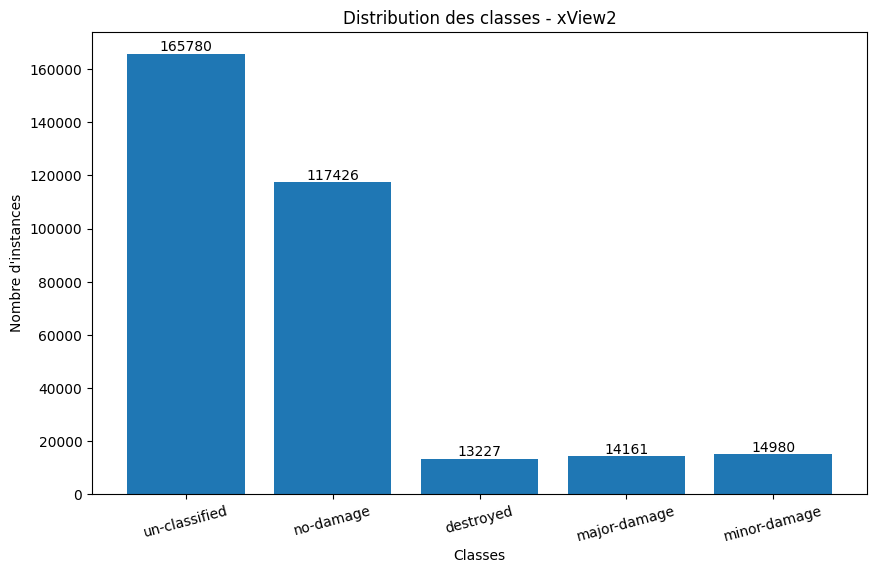

In [1]:
# ============================================================
# ANALYSE DES CLASSES xView2
# ============================================================

import os
import json
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from tqdm import tqdm

# ── PATH LABELS ─────────────────────────────────────────────
BASE = "/kaggle/input/datasets/tunguz/xview2-challenge-dataset-train-and-test"
TRAIN_LBL = os.path.join(BASE, "train/train/labels")

# ── CLASSES ────────────────────────────────────────────────
classes = [
    "no-damage",
    "minor-damage",
    "major-damage",
    "destroyed",
    "un-classified"
]

# ── COMPTEUR ───────────────────────────────────────────────
counter = Counter()

# ── LECTURE DES JSON ───────────────────────────────────────
json_files = [f for f in os.listdir(TRAIN_LBL) if f.endswith(".json")]

print("Nombre de fichiers JSON :", len(json_files))

for jf in tqdm(json_files):

    path = os.path.join(TRAIN_LBL, jf)

    with open(path) as f:
        data = json.load(f)

    features = data["features"].get("xy", [])

    for feat in features:

        subtype = feat["properties"].get(
            "subtype",
            "un-classified"
        )

        counter[subtype] += 1

# ── DATAFRAME ──────────────────────────────────────────────
df = pd.DataFrame({
    "Classe": list(counter.keys()),
    "Nombre": list(counter.values())
})

# ── AFFICHAGE TABLEAU ──────────────────────────────────────
print("\nDistribution des classes :\n")
print(df)

# ── HISTOGRAMME ────────────────────────────────────────────
plt.figure(figsize=(10,6))

bars = plt.bar(
    df["Classe"],
    df["Nombre"]
)

# Affichage des valeurs sur les barres
for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        yval,
        int(yval),
        ha='center',
        va='bottom'
    )

plt.title("Distribution des classes - xView2")
plt.xlabel("Classes")
plt.ylabel("Nombre d'instances")

plt.xticks(rotation=15)

plt.show()

In [1]:
# ============================================================
# PRETRAITEMENT AVANCE xView2
# Gestion du déséquilibre + augmentation + PRE/POST
# ============================================================

# ── IMPORTS ─────────────────────────────────────────────────
import os
import json
import random
import numpy as np
import cv2
import torch

from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

import albumentations as A
from albumentations.pytorch import ToTensorV2

# ── PATHS ──────────────────────────────────────────────────
BASE = "/kaggle/input/datasets/tunguz/xview2-challenge-dataset-train-and-test"

TRAIN_IMG = os.path.join(BASE, "train/train/images")
TRAIN_LBL = os.path.join(BASE, "train/train/labels")

print("Images :", len(os.listdir(TRAIN_IMG)))
print("Labels :", len(os.listdir(TRAIN_LBL)))

# ============================================================
# 1. CLASSES
# ============================================================

# On ignore volontairement "un-classified"

DAMAGE_CLASSES = {
    'no-damage': 1,
    'minor-damage': 2,
    'major-damage': 3,
    'destroyed': 4
}

# ============================================================
# 2. JSON → MASK
# ============================================================

from shapely.wkt import loads as wkt_loads

def json_to_mask(json_path, size=1024):

    mask = np.zeros((size, size), dtype=np.uint8)

    with open(json_path) as f:
        data = json.load(f)

    for feat in data['features'].get('xy', []):

        subtype = feat['properties'].get('subtype')

        # ignorer les classes inconnues
        if subtype not in DAMAGE_CLASSES:
            continue

        cls = DAMAGE_CLASSES[subtype]

        wkt = feat.get('wkt', '')

        try:
            poly = wkt_loads(wkt)

            coords = np.array(
                poly.exterior.coords,
                dtype=np.int32
            )

            cv2.fillPoly(mask, [coords], cls)

        except:
            pass

    # éliminer les masques presque vides
    if np.sum(mask > 0) < 500:
        return None

    return mask

# ============================================================
# 3. CREATION DES PAIRES
# ============================================================

all_files = os.listdir(TRAIN_IMG)

post_files = [
    f for f in all_files
    if "_post_disaster" in f
]

pairs = []

for pf in post_files:

    base = pf.replace("_post_disaster.png", "")

    pre = os.path.join(
        TRAIN_IMG,
        base + "_pre_disaster.png"
    )

    post = os.path.join(
        TRAIN_IMG,
        base + "_post_disaster.png"
    )

    lbl = os.path.join(
        TRAIN_LBL,
        base + "_post_disaster.json"
    )

    if (
        os.path.exists(pre)
        and os.path.exists(post)
        and os.path.exists(lbl)
    ):

        pairs.append({
            "pre": pre,
            "post": post,
            "label": lbl
        })

print("Pairs originales :", len(pairs))

# ============================================================
# 4. OVERSAMPLING DES CLASSES RARES
# ============================================================
balanced_pairs = []

for p in pairs:

    with open(p["label"]) as f:
        data = json.load(f)

    text = str(data)

    # 🔴 no-damage → sous-échantillonnage
    if "no-damage" in text:
        if np.random.rand() < 0.3:
            balanced_pairs.append(p)

    # 🔥 classes rares → oversampling
    elif "destroyed" in text:
        balanced_pairs.extend([p] * 6)

    elif "major-damage" in text:
        balanced_pairs.extend([p] * 4)

    elif "minor-damage" in text:
        balanced_pairs.extend([p] * 2)

    else:
        balanced_pairs.append(p)

print("Pairs après balancing :", len(balanced_pairs))



# ============================================================
# 5. TRAIN / VALIDATION SPLIT
# ============================================================

train_pairs, val_pairs = train_test_split(
    pairs,
    test_size=0.2,
    random_state=42
)

print("Train :", len(train_pairs))
print("Validation :", len(val_pairs))

# ============================================================
# 6. DATA AUGMENTATION AVANCEE
# ============================================================

transform = A.Compose([

    A.Resize(256, 256),

    # flips
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),

    # rotations
    A.RandomRotate90(p=0.5),

    # transformations géométriques
    A.ShiftScaleRotate(
        shift_limit=0.08,
        scale_limit=0.15,
        rotate_limit=30,
        border_mode=cv2.BORDER_REFLECT,
        p=0.5
    ),

    # luminosité / contraste
    A.RandomBrightnessContrast(
        brightness_limit=0.2,
        contrast_limit=0.2,
        p=0.5
    ),

    # bruit
    A.GaussNoise(
        std_range=(0.02, 0.08),
        p=0.3
    ),

    # blur
    A.GaussianBlur(
        blur_limit=(3, 5),
        p=0.2
    ),

    # amélioration contraste satellite
    A.CLAHE(
        clip_limit=2.0,
        p=0.3
    ),

    A.Normalize(),

    ToTensorV2()

])

# ============================================================
# 7. DATASET PYTORCH
# ============================================================

class XViewDataset(Dataset):

    def __init__(self, pairs):
        self.pairs = pairs

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):

        p = self.pairs[idx]

        # ── IMAGE PRE ─────────────────────────────
        pre = cv2.imread(p["pre"])

        pre = cv2.cvtColor(
            pre,
            cv2.COLOR_BGR2RGB
        )

        # ── IMAGE POST ────────────────────────────
        post = cv2.imread(p["post"])

        post = cv2.cvtColor(
            post,
            cv2.COLOR_BGR2RGB
        )

        # ── CONCAT PRE + POST → 6 CANAUX ─────────
        img = np.concatenate(
            [pre, post],
            axis=2
        )

        # ── MASK ──────────────────────────────────
        mask = json_to_mask(p["label"])

        # si image vide → prendre une autre image
        if mask is None:

            return self.__getitem__(
                random.randint(
                    0,
                    len(self.pairs)-1
                )
            )

        # ── AUGMENTATION IMAGE + MASK ────────────
        aug = transform(
            image=img,
            mask=mask
        )

        img = aug["image"]

        mask = aug["mask"]

        mask = torch.tensor(mask).long()

        return img, mask

# ============================================================
# 8. DATALOADERS
# ============================================================

train_dataset = XViewDataset(train_pairs)
val_dataset   = XViewDataset(val_pairs)

train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=4,
    shuffle=False,
    num_workers=2
)

print("Pretraitement prêt.")
print("Train batches :", len(train_loader))
print("Validation batches :", len(val_loader))

# ============================================================
# 9. CALCUL AUTOMATIQUE DES POIDS
# ============================================================

counts = np.array([
    117426,  # no-damage
    14980,   # minor
    14161,   # major
    13227    # destroyed
])

freq = counts / counts.sum()

weights = 1 / np.sqrt(freq)

weights = weights / weights.sum()

weights = torch.tensor(
    [0.01] + list(weights),
    dtype=torch.float32
)

print("\nPoids des classes :")
print(weights)

Images : 5598
Labels : 5598
Pairs originales : 2799
Pairs après balancing : 3652
Train : 2239
Validation : 560
Pretraitement prêt.
Train batches : 560
Validation batches : 140

Poids des classes :
tensor([0.0100, 0.1035, 0.2899, 0.2981, 0.3085])


/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


In [ ]:
# ============================================================
# VISUALISATION DES CLASSES APRES PRETRAITEMENT
# ============================================================

import json
import matplotlib.pyplot as plt
from collections import Counter
from tqdm import tqdm

counter = Counter()

# on parcourt les labels des pairs APRES équilibrage
for p in tqdm(train_pairs):

    with open(p["label"]) as f:
        data = json.load(f)

    for feat in data["features"].get("xy", []):

        subtype = feat["properties"].get("subtype")

        if subtype is None:
            continue

        counter[subtype] += 1


# conversion en tableau
classes = list(counter.keys())
values = list(counter.values())

print("\nDistribution APRES pretraitement :")
for c, v in zip(classes, values):
    print(c, ":", v)

# ============================================================
# HISTOGRAMME
# ============================================================

plt.figure(figsize=(10,6))

bars = plt.bar(classes, values)

# valeurs sur les barres
for bar in bars:
    y = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        y,
        int(y),
        ha='center',
        va='bottom'
    )

plt.title("Distribution des classes après prétraitement")
plt.xlabel("Classes")
plt.ylabel("Nombre d'instances")
plt.xticks(rotation=20)
plt.show()# ============================================================
# VISUALISATION DES CLASSES APRES PRETRAITEMENT
# ============================================================

import json
import matplotlib.pyplot as plt
from collections import Counter
from tqdm import tqdm

counter = Counter()

# on parcourt les labels des pairs APRES équilibrage
for p in tqdm(train_pairs):

    with open(p["label"]) as f:
        data = json.load(f)

    for feat in data["features"].get("xy", []):

        subtype = feat["properties"].get("subtype")

        if subtype is None:
            continue

        counter[subtype] += 1


# conversion en tableau
classes = list(counter.keys())
values = list(counter.values())

print("\nDistribution APRES pretraitement :")
for c, v in zip(classes, values):
    print(c, ":", v)

# ============================================================
# HISTOGRAMME
# ============================================================

plt.figure(figsize=(10,6))

bars = plt.bar(classes, values)

# valeurs sur les barres
for bar in bars:
    y = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        y,
        int(y),
        ha='center',
        va='bottom'
    )

plt.title("Distribution des classes après prétraitement")
plt.xlabel("Classes")
plt.ylabel("Nombre d'instances")
plt.xticks(rotation=20)
plt.show()

Device: cuda
Pairs: 2799

Epoch 1
Train Loss: 0.32937143331925783
Val Loss: 0.19194855115243367
Val IoU: 0.36746525534025626

Epoch 2
Train Loss: 0.17256031121526447
Val Loss: 0.13996334445795844
Val IoU: 0.4208914283558811

Epoch 3
Train Loss: 0.14595808779953845
Val Loss: 0.12271679842046329
Val IoU: 0.53480589730399

Epoch 4
Train Loss: 0.13457498996119413
Val Loss: 0.11386259548099978
Val IoU: 0.53480589730399

Epoch 5
Train Loss: 0.12907154774293303
Val Loss: 0.10646356602332421
Val IoU: 0.53480589730399


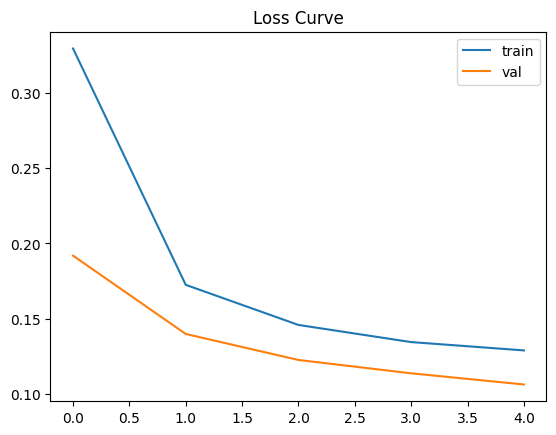

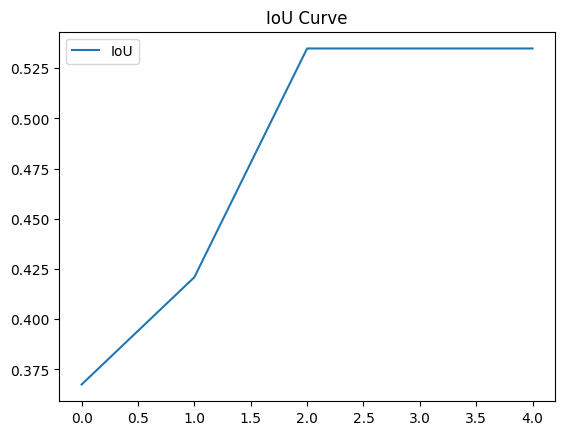

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8096584..2.2489083].


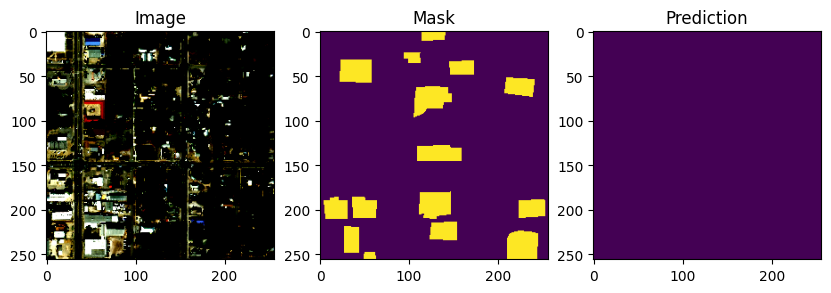

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.6384108..2.2489083].


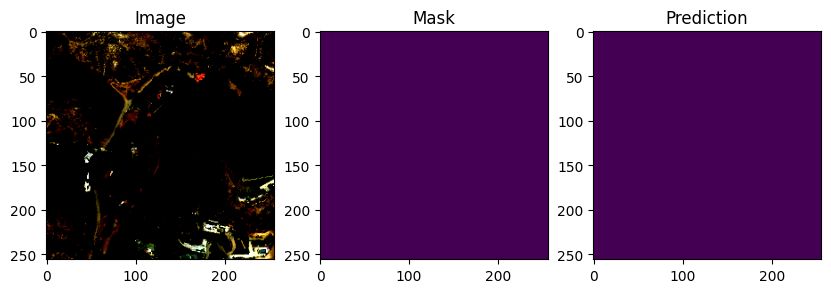

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9980307..2.2489083].


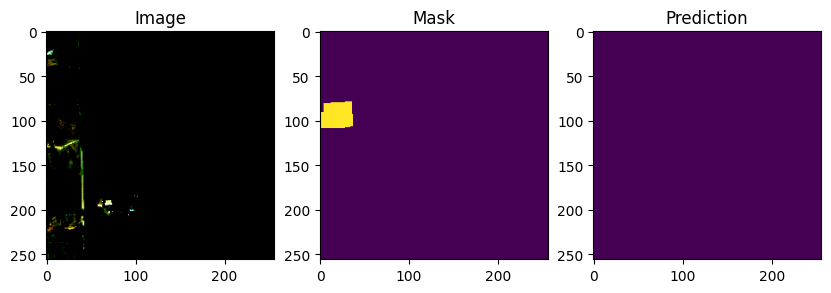

In [2]:
# ============================================================
# xView2 - FINAL TRAINING PIPELINE (CLEAN + STABLE)
# ============================================================

import os, json, cv2, numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import albumentations as A
from albumentations.pytorch import ToTensorV2

from sklearn.model_selection import train_test_split

# ============================================================
# DEVICE
# ============================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ============================================================
# PATHS
# ============================================================
BASE = "/kaggle/input/datasets/tunguz/xview2-challenge-dataset-train-and-test"
TRAIN_IMG = os.path.join(BASE, "train/train/images")
TRAIN_LBL = os.path.join(BASE, "train/train/labels")

NUM_CLASSES = 5
IMG_SIZE = 256

# ============================================================
# MASK
# ============================================================
from shapely.wkt import loads as wkt_loads

def json_to_mask(json_path):
    mask = np.zeros((IMG_SIZE, IMG_SIZE), dtype=np.uint8)

    with open(json_path) as f:
        data = json.load(f)

    for feat in data['features'].get('xy', []):
        try:
            poly = wkt_loads(feat['wkt'])
            coords = np.array(poly.exterior.coords, dtype=np.int32)
            cv2.fillPoly(mask, [coords], 1)
        except:
            pass

    return mask

# ============================================================
# PAIRS
# ============================================================
all_files = os.listdir(TRAIN_IMG)
post_files = [f for f in all_files if "_post_disaster" in f]

pairs = []
for pf in post_files:
    base = pf.replace("_post_disaster.png", "")

    pre = os.path.join(TRAIN_IMG, base + "_pre_disaster.png")
    post = os.path.join(TRAIN_IMG, base + "_post_disaster.png")
    lbl = os.path.join(TRAIN_LBL, base + "_post_disaster.json")

    if os.path.exists(pre) and os.path.exists(post) and os.path.exists(lbl):
        pairs.append({"pre": pre, "post": post, "label": lbl})

print("Pairs:", len(pairs))

# ============================================================
# SPLIT
# ============================================================
train_pairs, val_pairs = train_test_split(pairs, test_size=0.2, random_state=42)

# ============================================================
# TRANSFORM
# ============================================================
transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.3),
    A.Normalize(),
    ToTensorV2()
])

# ============================================================
# DATASET (FIXED INDENTATION + SAFE)
# ============================================================
class XDataset(Dataset):
    def __init__(self, pairs):
        self.pairs = pairs

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):

        p = self.pairs[idx]

        pre = cv2.imread(p["pre"])
        post = cv2.imread(p["post"])

        pre = cv2.cvtColor(pre, cv2.COLOR_BGR2RGB)
        post = cv2.cvtColor(post, cv2.COLOR_BGR2RGB)

        img = np.concatenate([pre, post], axis=2)

        mask = json_to_mask(p["label"])

        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        mask = cv2.resize(mask, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_NEAREST)

        aug = transform(image=img, mask=mask)

        img = aug["image"]
        mask = aug["mask"]

        mask = torch.as_tensor(mask, dtype=torch.long)

        return img, mask

train_loader = DataLoader(XDataset(train_pairs), batch_size=4, shuffle=True, num_workers=2)
val_loader   = DataLoader(XDataset(val_pairs), batch_size=4, shuffle=False, num_workers=2)

# ============================================================
# U-NET
# ============================================================
class DoubleConv(nn.Module):
    def __init__(self,in_c,out_c):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_c,out_c,3,padding=1),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_c,out_c,3,padding=1),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True)
        )

    def forward(self,x):
        return self.net(x)

class UNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.d1=DoubleConv(6,64)
        self.d2=DoubleConv(64,128)
        self.d3=DoubleConv(128,256)

        self.p=nn.MaxPool2d(2)

        self.b=DoubleConv(256,512)

        self.u3=nn.ConvTranspose2d(512,256,2,2)
        self.c3=DoubleConv(512,256)

        self.u2=nn.ConvTranspose2d(256,128,2,2)
        self.c2=DoubleConv(256,128)

        self.u1=nn.ConvTranspose2d(128,64,2,2)
        self.c1=DoubleConv(128,64)

        self.out=nn.Conv2d(64,NUM_CLASSES,1)

    def forward(self,x):

        d1=self.d1(x)
        d2=self.d2(self.p(d1))
        d3=self.d3(self.p(d2))

        b=self.b(self.p(d3))

        u3=self.c3(torch.cat([self.u3(b),d3],1))
        u2=self.c2(torch.cat([self.u2(u3),d2],1))
        u1=self.c1(torch.cat([self.u1(u2),d1],1))

        return self.out(u1)

model = UNet().to(device)

# ============================================================
# FOCAL LOSS + DICE
# ============================================================
class FocalLoss(nn.Module):
    def __init__(self, gamma=2):
        super().__init__()
        self.gamma = gamma

    def forward(self, pred, target):
        ce = F.cross_entropy(pred, target, reduction='none')
        pt = torch.exp(-ce)
        return ((1 - pt) ** self.gamma * ce).mean()

class DiceLoss(nn.Module):
    def forward(self, pred, target):

        pred = F.softmax(pred, dim=1)
        target = F.one_hot(target, NUM_CLASSES).permute(0,3,1,2).float()

        inter = (pred * target).sum()
        union = pred.sum() + target.sum()

        return 1 - (2 * inter + 1e-6) / (union + 1e-6)

focal = FocalLoss()
dice = DiceLoss()

def loss_fn(p,t):
    return 0.5*focal(p,t) + 0.5*dice(p,t)

# ============================================================
# METRICS
# ============================================================
def metrics(pred, mask):

    pred = torch.argmax(pred,1)

    acc = (pred == mask).float().mean().item()

    ious = []

    for c in range(NUM_CLASSES):
        inter = ((pred==c)&(mask==c)).sum().float()
        union = ((pred==c)|(mask==c)).sum().float()

        if union > 0:
            ious.append((inter/union).item())

    return acc, np.mean(ious)

# ============================================================
# TRAINING
# ============================================================
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

train_losses, val_losses, val_ious = [], [], []

EPOCHS = 5

for epoch in range(EPOCHS):

    model.train()
    train_loss = 0

    for imgs, masks in train_loader:

        imgs = imgs.float().to(device)
        masks = masks.to(device)

        optimizer.zero_grad()

        out = model(imgs)
        loss = loss_fn(out, masks)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    model.eval()

    val_loss = 0
    ious = []

    with torch.no_grad():

        for imgs, masks in val_loader:

            imgs = imgs.float().to(device)
            masks = masks.to(device)

            out = model(imgs)

            loss = loss_fn(out, masks)
            val_loss += loss.item()

            _, iou = metrics(out, masks)
            ious.append(iou)

    train_losses.append(train_loss/len(train_loader))
    val_losses.append(val_loss/len(val_loader))
    val_ious.append(np.mean(ious))

    print(f"\nEpoch {epoch+1}")
    print("Train Loss:", train_losses[-1])
    print("Val Loss:", val_losses[-1])
    print("Val IoU:", val_ious[-1])

# ============================================================
# CURVES
# ============================================================
plt.plot(train_losses, label="train")
plt.plot(val_losses, label="val")
plt.legend()
plt.title("Loss Curve")
plt.show()

plt.plot(val_ious, label="IoU")
plt.legend()
plt.title("IoU Curve")
plt.show()

# ============================================================
# VISUALIZATION
# ============================================================
def visualize(model, dataset, n=3):

    model.eval()

    for i in range(n):

        img, mask = dataset[i]

        with torch.no_grad():
            pred = model(img.unsqueeze(0).float().to(device))
            pred = torch.argmax(pred,1).cpu().squeeze()

        plt.figure(figsize=(10,3))

        plt.subplot(1,3,1)
        plt.title("Image")
        plt.imshow(img[:3].permute(1,2,0))

        plt.subplot(1,3,2)
        plt.title("Mask")
        plt.imshow(mask)

        plt.subplot(1,3,3)
        plt.title("Prediction")
        plt.imshow(pred)

        plt.show()

visualize(model, XDataset(val_pairs))

In [ ]:
!pip install segmentation-models-pytorch -q

In [ ]:
import importlib
import segmentation_models_pytorch as smp

In [60]:
import os, json, cv2, numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import albumentations as A
from albumentations.pytorch import ToTensorV2

from sklearn.model_selection import train_test_split

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [69]:
BASE = "/kaggle/input/datasets/tunguz/xview2-challenge-dataset-train-and-test"

IMG_DIR = os.path.join(BASE, "train/train/images")
LBL_DIR = os.path.join(BASE, "train/train/labels")

IMG_SIZE = 256
NUM_CLASSES = 5

In [71]:
from shapely.wkt import loads as wkt_loads

def json_to_mask(path):
    mask = np.zeros((IMG_SIZE, IMG_SIZE), dtype=np.uint8)

    with open(path) as f:
        data = json.load(f)

    for feat in data["features"].get("xy", []):
        try:
            poly = wkt_loads(feat["wkt"])
            coords = np.array(poly.exterior.coords, dtype=np.int32)
            cv2.fillPoly(mask, [coords], 1)
        except:
            pass

    return mask

In [72]:
files = os.listdir(IMG_DIR)
post_files = [f for f in files if "_post_disaster" in f]

pairs = []

for f in post_files:
    base = f.replace("_post_disaster.png", "")

    pre = os.path.join(IMG_DIR, base + "_pre_disaster.png")
    post = os.path.join(IMG_DIR, base + "_post_disaster.png")
    lbl = os.path.join(LBL_DIR, base + "_post_disaster.json")

    if os.path.exists(pre) and os.path.exists(post) and os.path.exists(lbl):
        pairs.append({"pre": pre, "post": post, "label": lbl})

print("Pairs:", len(pairs))

Pairs: 2799


In [80]:
train_pairs, val_pairs = train_test_split(pairs, test_size=0.2, random_state=42)

In [95]:
transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.3),
    A.Normalize(),
    ToTensorV2()
])

In [102]:
class XDataset(Dataset):

    def __init__(self, pairs):
        self.pairs = pairs

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):

        p = self.pairs[idx]

        pre = cv2.imread(p["pre"])
        post = cv2.imread(p["post"])

        pre = cv2.cvtColor(pre, cv2.COLOR_BGR2RGB)
        post = cv2.cvtColor(post, cv2.COLOR_BGR2RGB)

        img = np.concatenate([pre, post], axis=2)

        mask = json_to_mask(p["label"])

        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        mask = cv2.resize(mask, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_NEAREST)

        aug = transform(image=img, mask=mask)

        img = aug["image"]
        mask = aug["mask"].long()

        return img, mask

In [106]:
train_loader = DataLoader(XDataset(train_pairs), batch_size=4, shuffle=True, num_workers=2)
val_loader = DataLoader(XDataset(val_pairs), batch_size=4, shuffle=False, num_workers=2)

In [107]:
class DoubleConv(nn.Module):
    def __init__(self,in_c,out_c):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_c,out_c,3,padding=1),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_c,out_c,3,padding=1),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True)
        )

    def forward(self,x):
        return self.net(x)


class UNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.d1=DoubleConv(6,64)
        self.d2=DoubleConv(64,128)
        self.d3=DoubleConv(128,256)
        self.b=DoubleConv(256,512)

        self.p=nn.MaxPool2d(2)

        self.u3=nn.ConvTranspose2d(512,256,2,2)
        self.c3=DoubleConv(512,256)

        self.u2=nn.ConvTranspose2d(256,128,2,2)
        self.c2=DoubleConv(256,128)

        self.u1=nn.ConvTranspose2d(128,64,2,2)
        self.c1=DoubleConv(128,64)

        self.out=nn.Conv2d(64,NUM_CLASSES,1)

    def forward(self,x):

        d1=self.d1(x)
        d2=self.d2(self.p(d1))
        d3=self.d3(self.p(d2))
        b=self.b(self.p(d3))

        u3=self.c3(torch.cat([self.u3(b),d3],1))
        u2=self.c2(torch.cat([self.u2(u3),d2],1))
        u1=self.c1(torch.cat([self.u1(u2),d1],1))

        return self.out(u1)

model = UNet().to(device)
print("Model OK")

Model OK


In [111]:
class FocalLoss(nn.Module):
    def __init__(self,gamma=2):
        super().__init__()
        self.gamma=gamma

    def forward(self,pred,target):
        ce = F.cross_entropy(pred,target,reduction='none')
        pt = torch.exp(-ce)
        return ((1-pt)**self.gamma * ce).mean()


class DiceLoss(nn.Module):
    def forward(self,pred,target):

        pred = F.softmax(pred,dim=1)
        target = F.one_hot(target,NUM_CLASSES).permute(0,3,1,2).float()

        inter = (pred*target).sum()
        union = pred.sum() + target.sum()

        return 1 - (2*inter+1e-6)/(union+1e-6)


focal = FocalLoss()
dice = DiceLoss()

def loss_fn(p,t):
    return 0.5*focal(p,t) + 0.5*dice(p,t)

In [113]:
def metrics(pred,mask):

    pred = torch.argmax(pred,1)

    acc = (pred==mask).float().mean().item()

    iou=[]

    for c in range(NUM_CLASSES):
        inter = ((pred==c)&(mask==c)).sum().float()
        union = ((pred==c)|(mask==c)).sum().float()

        if union>0:
            iou.append((inter/union).item())

    return acc, np.mean(iou)

In [114]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

train_losses=[]
val_losses=[]
val_ious=[]

EPOCHS=5

for epoch in range(EPOCHS):

    model.train()
    train_loss=0

    for imgs,masks in train_loader:

        imgs = imgs.float().to(device)
        masks = masks.to(device)

        optimizer.zero_grad()
        out = model(imgs)

        loss = loss_fn(out,masks)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    model.eval()
    val_loss=0
    ious=[]

    with torch.no_grad():
        for imgs,masks in val_loader:

            imgs = imgs.float().to(device)
            masks = masks.to(device)

            out = model(imgs)

            loss = loss_fn(out,masks)
            val_loss += loss.item()

            _,iou = metrics(out,masks)
            ious.append(iou)

    train_losses.append(train_loss/len(train_loader))
    val_losses.append(val_loss/len(val_loader))
    val_ious.append(np.mean(ious))

    print(f"\nEpoch {epoch+1}")
    print("Train Loss:",train_losses[-1])
    print("Val Loss:",val_losses[-1])
    print("Val IoU:",val_ious[-1])


Epoch 1
Train Loss: 0.41794017500111036
Val Loss: 0.224380888151271
Val IoU: 0.448646665020507

Epoch 2
Train Loss: 0.19517349445128016
Val Loss: 0.14791051750736578
Val IoU: 0.5313216787297279

Epoch 3
Train Loss: 0.15420318623073398
Val Loss: 0.12929962929338218
Val IoU: 0.53480589730399

Epoch 4
Train Loss: 0.14032684857291836
Val Loss: 0.11190744896552392
Val IoU: 0.53480589730399

Epoch 5
Train Loss: 0.13254749227448234
Val Loss: 0.11125011582459722
Val IoU: 0.53480589730399


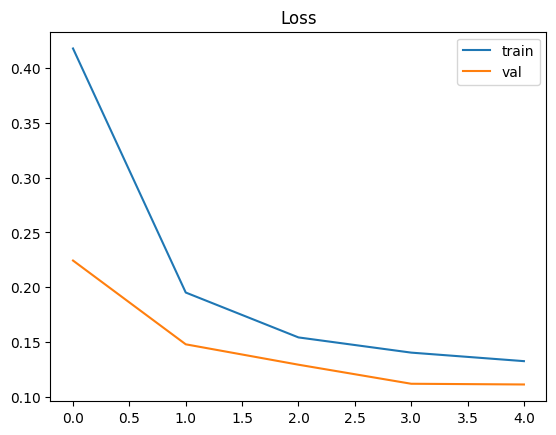

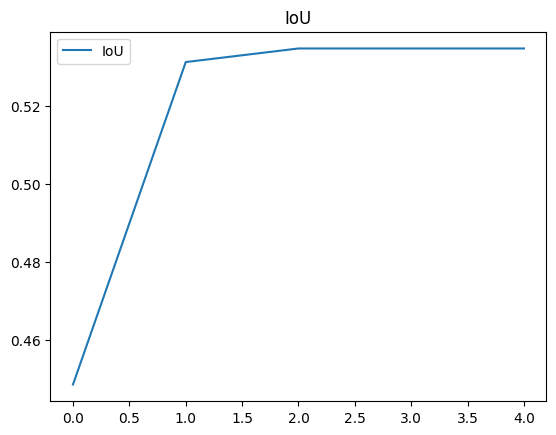

In [115]:
plt.plot(train_losses,label="train")
plt.plot(val_losses,label="val")
plt.legend()
plt.title("Loss")
plt.show()

plt.plot(val_ious,label="IoU")
plt.legend()
plt.title("IoU")
plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..1.152924].


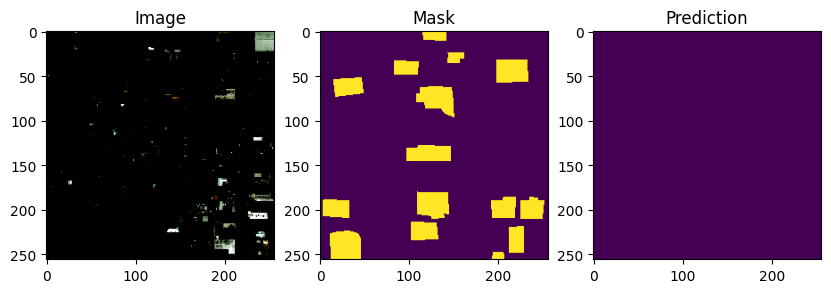

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.6384108..1.5810428].


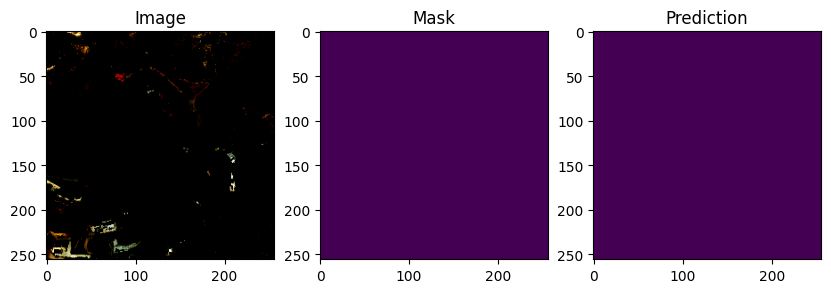

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9980307..2.2489083].


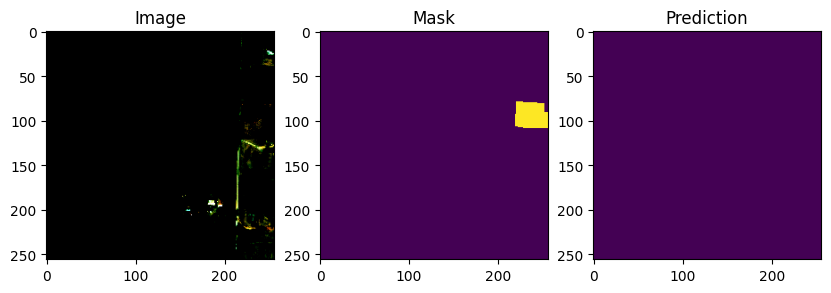

In [116]:
def visualize(model,dataset,n=3):

    model.eval()

    for i in range(n):

        img,mask = dataset[i]

        with torch.no_grad():
            pred = model(img.unsqueeze(0).float().to(device))
            pred = torch.argmax(pred,1).cpu().squeeze()

        plt.figure(figsize=(10,3))

        plt.subplot(1,3,1)
        plt.title("Image")
        plt.imshow(img[:3].permute(1,2,0))

        plt.subplot(1,3,2)
        plt.title("Mask")
        plt.imshow(mask)

        plt.subplot(1,3,3)
        plt.title("Prediction")
        plt.imshow(pred)

        plt.show()

visualize(model, XDataset(val_pairs))

Device: cuda


/tmp/ipykernel_57/1483298792.py:143: UserWarning: Argument(s) 'mode' are not valid for transform Affine
  A.Affine(


Paires trouvées : 2799
Train après oversampling : 5533
Train : 5533 | Val : 560
  Paires valides : 4677/5533

Modèle : U-Net + ResNet34 | Paramètres : 24,446,357

DÉBUT DE L'ENTRAÎNEMENT
  Paires valides : 402/560
  Paires valides : 402/560
  Paires valides : 402/560
Epoch 01/15 | Train Loss: 0.1139 | Val Loss: 0.0521 | Val IoU: 0.0753 ← BEST
Epoch 02/15 | Train Loss: 0.0487 | Val Loss: 0.0436 | Val IoU: 0.0884 ← BEST
Epoch 03/15 | Train Loss: 0.0437 | Val Loss: 0.0417 | Val IoU: 0.1072 ← BEST
Epoch 04/15 | Train Loss: 0.0410 | Val Loss: 0.0386 | Val IoU: 0.1348 ← BEST
Epoch 05/15 | Train Loss: 0.0392 | Val Loss: 0.0405 | Val IoU: 0.1548 ← BEST
Epoch 06/15 | Train Loss: 0.0371 | Val Loss: 0.0360 | Val IoU: 0.1743 ← BEST
Epoch 07/15 | Train Loss: 0.0355 | Val Loss: 0.0341 | Val IoU: 0.1854 ← BEST
Epoch 08/15 | Train Loss: 0.0342 | Val Loss: 0.0350 | Val IoU: 0.1871 ← BEST
Epoch 09/15 | Train Loss: 0.0331 | Val Loss: 0.0328 | Val IoU: 0.2068 ← BEST
Epoch 10/15 | Train Loss: 0.0325 | Val 

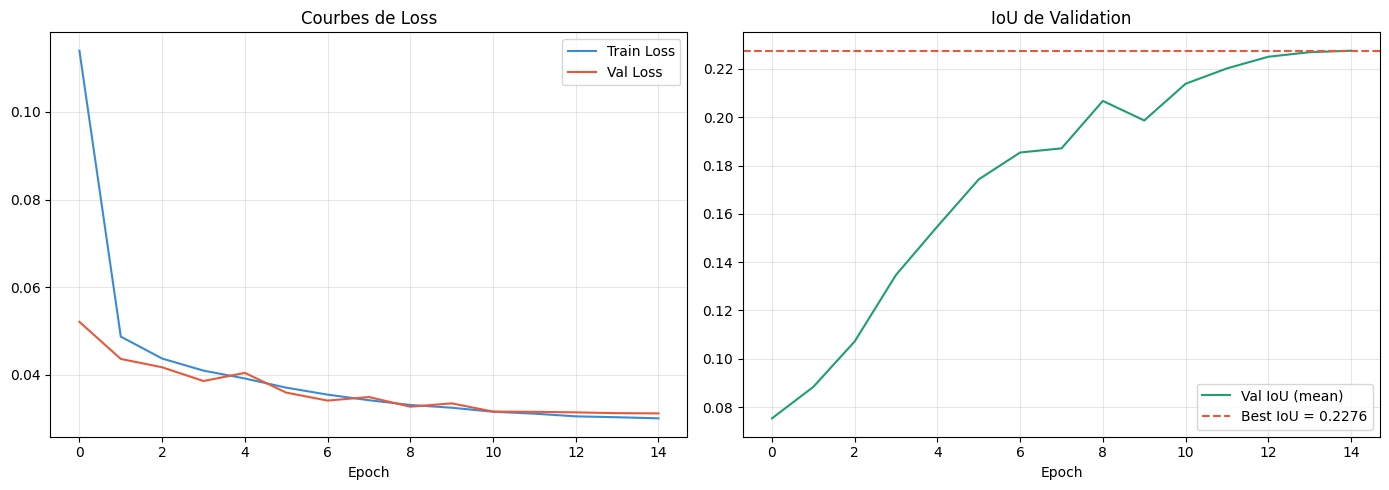


Chargement du meilleur modèle...


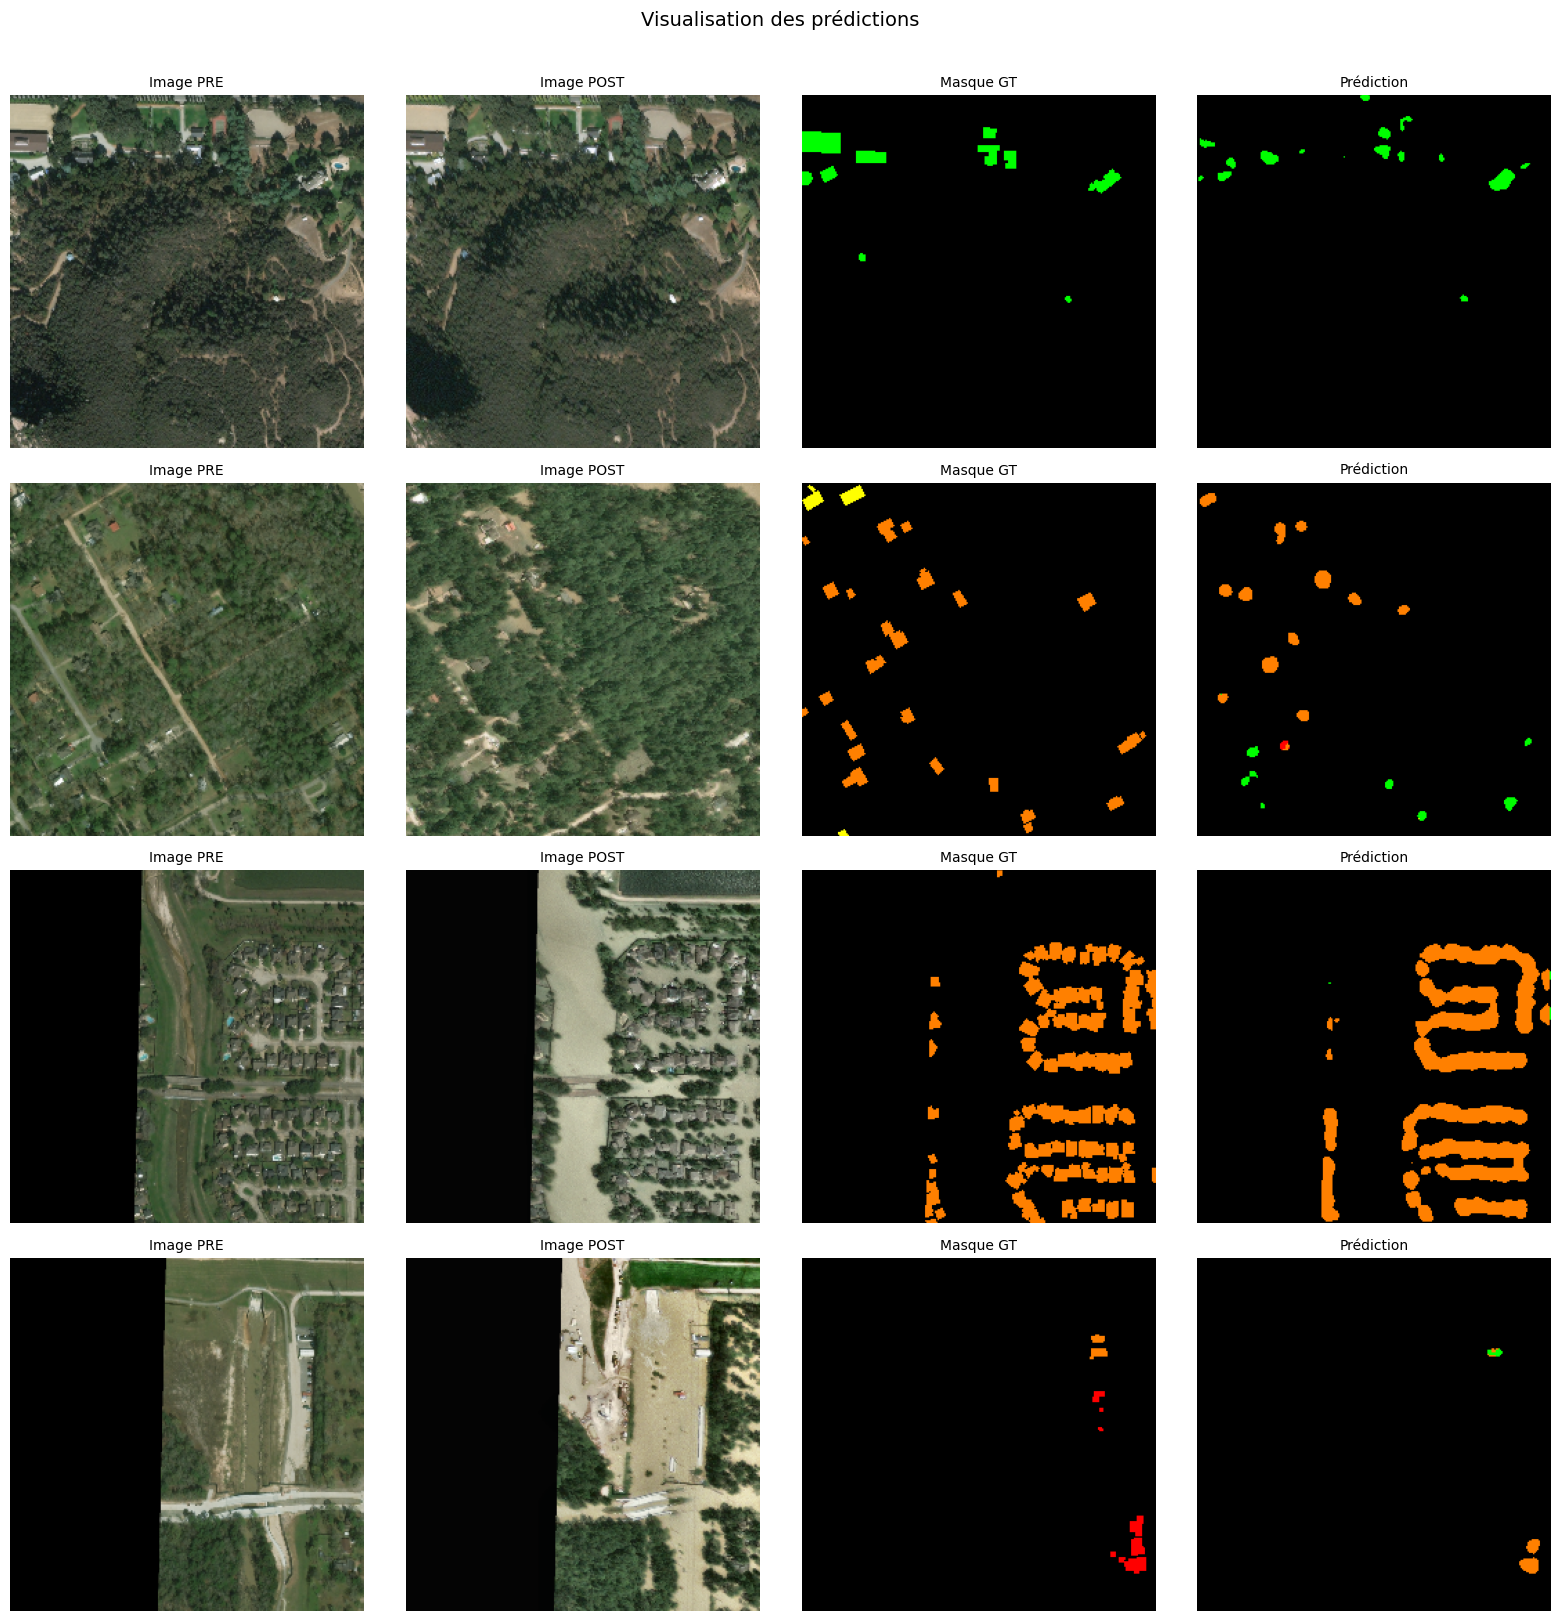


IoU PAR CLASSE (meilleur modèle)
  Classe 1 (no-damage      ) : IoU = 0.4920
  Classe 2 (minor-damage   ) : IoU = 0.0409
  Classe 3 (major-damage   ) : IoU = 0.1508
  Classe 4 (destroyed      ) : IoU = 0.2222


In [117]:
# ============================================================
# xView2 — PIPELINE COMPLET V3
# Corrections : CLAHE 6 canaux + masque multi-classes
# ============================================================

# !pip install segmentation-models-pytorch -q

# ── IMPORTS ─────────────────────────────────────────────────
import os
import json
import random
import numpy as np
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from shapely.wkt import loads as wkt_loads

import albumentations as A
from albumentations.pytorch import ToTensorV2

import segmentation_models_pytorch as smp

# ============================================================
# CONFIG GLOBALE
# ============================================================
BASE       = "/kaggle/input/datasets/tunguz/xview2-challenge-dataset-train-and-test"
TRAIN_IMG  = os.path.join(BASE, "train/train/images")
TRAIN_LBL  = os.path.join(BASE, "train/train/labels")

IMG_SIZE    = 256
NUM_CLASSES = 5        # 0=background, 1=no-damage, 2=minor, 3=major, 4=destroyed
BATCH_SIZE  = 8
EPOCHS      = 15
LR          = 1e-4

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

# ============================================================
# CLASSES DE DOMMAGES
# ============================================================
DAMAGE_CLASSES = {
    'no-damage'    : 1,
    'minor-damage' : 2,
    'major-damage' : 3,
    'destroyed'    : 4,
}

# ============================================================
# 1. JSON → MASK MULTI-CLASSES
# ============================================================
def json_to_mask(json_path):
    mask  = np.zeros((IMG_SIZE, IMG_SIZE), dtype=np.uint8)
    scale = IMG_SIZE / 1024.0

    with open(json_path) as f:
        data = json.load(f)

    for feat in data['features'].get('xy', []):
        subtype = feat['properties'].get('subtype')
        cls     = DAMAGE_CLASSES.get(subtype)
        if cls is None:
            continue
        try:
            poly   = wkt_loads(feat['wkt'])
            coords = (
                np.array(poly.exterior.coords, dtype=np.float32) * scale
            ).astype(np.int32)
            cv2.fillPoly(mask, [coords], cls)
        except Exception:
            pass

    if np.sum(mask > 0) < 100:
        return None

    return mask


# ============================================================
# 2. CRÉATION DES PAIRES PRE/POST
# ============================================================
def build_pairs():
    post_files = [
        f for f in os.listdir(TRAIN_IMG)
        if "_post_disaster" in f
    ]
    pairs = []
    for pf in post_files:
        base = pf.replace("_post_disaster.png", "")
        pre  = os.path.join(TRAIN_IMG, base + "_pre_disaster.png")
        post = os.path.join(TRAIN_IMG, base + "_post_disaster.png")
        lbl  = os.path.join(TRAIN_LBL, base + "_post_disaster.json")
        if os.path.exists(pre) and os.path.exists(post) and os.path.exists(lbl):
            pairs.append({"pre": pre, "post": post, "label": lbl})
    print(f"Paires trouvées : {len(pairs)}")
    return pairs


# ============================================================
# 3. OVERSAMPLING (sur train uniquement, après split)
# ============================================================
def oversample(pairs):
    balanced = []
    for p in pairs:
        with open(p["label"]) as f:
            text = f.read()
        if "destroyed" in text:
            balanced.extend([p] * 5)
        elif "major-damage" in text:
            balanced.extend([p] * 3)
        elif "minor-damage" in text:
            balanced.extend([p] * 2)
        elif "no-damage" in text:
            if random.random() < 0.4:
                balanced.append(p)
        else:
            balanced.append(p)
    random.shuffle(balanced)
    print(f"Train après oversampling : {len(balanced)}")
    return balanced


# ============================================================
# 4. AUGMENTATIONS
# ============================================================

# CLAHE séparé pour images 3 canaux
clahe_transform = A.Compose([
    A.CLAHE(clip_limit=2.0, p=0.3),
])

# Augmentations principales sur 6 canaux (sans CLAHE)
train_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.Affine(
        translate_percent=0.08,
        scale=(0.85, 1.15),
        rotate=(-30, 30),
        mode=cv2.BORDER_REFLECT,
        p=0.5
    ),
    A.RandomBrightnessContrast(
        brightness_limit=0.2,
        contrast_limit=0.2,
        p=0.5
    ),
    A.GaussNoise(std_range=(0.02, 0.08), p=0.3),
    A.GaussianBlur(blur_limit=(3, 5), p=0.2),
    A.Normalize(
        mean=[0.485, 0.456, 0.406, 0.485, 0.456, 0.406],
        std =[0.229, 0.224, 0.225, 0.229, 0.224, 0.225]
    ),
    ToTensorV2()
])

val_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(
        mean=[0.485, 0.456, 0.406, 0.485, 0.456, 0.406],
        std =[0.229, 0.224, 0.225, 0.229, 0.224, 0.225]
    ),
    ToTensorV2()
])


# ============================================================
# 5. DATASET
# ============================================================
class XViewDataset(Dataset):

    def __init__(self, pairs, transform):
        self.pairs     = pairs
        self.transform = transform
        self._valid    = None

    def _get_valid(self):
        if self._valid is None:
            self._valid = [
                p for p in self.pairs
                if json_to_mask(p["label"]) is not None
            ]
            print(f"  Paires valides : {len(self._valid)}/{len(self.pairs)}")
        return self._valid

    def __len__(self):
        return len(self._get_valid())

    def __getitem__(self, idx):
        p = self._get_valid()[idx]

        # ── Chargement ──────────────────────────────────────
        pre  = cv2.cvtColor(cv2.imread(p["pre"]),  cv2.COLOR_BGR2RGB)
        post = cv2.cvtColor(cv2.imread(p["post"]), cv2.COLOR_BGR2RGB)

        pre  = cv2.resize(pre,  (IMG_SIZE, IMG_SIZE))
        post = cv2.resize(post, (IMG_SIZE, IMG_SIZE))

        # ── CLAHE sur chaque image 3 canaux séparément ──────
        pre  = clahe_transform(image=pre)["image"]
        post = clahe_transform(image=post)["image"]

        # ── Concaténation → 6 canaux ────────────────────────
        img = np.concatenate([pre, post], axis=2)  # (H, W, 6)

        # ── Masque multi-classes ────────────────────────────
        mask = json_to_mask(p["label"])            # (H, W) valeurs 0-4

        # ── Augmentations + normalisation ───────────────────
        aug  = self.transform(image=img, mask=mask)
        img  = aug["image"]                        # Tensor (6, H, W)
        mask = torch.as_tensor(aug["mask"], dtype=torch.long)  # (H, W)

        return img, mask


# ============================================================
# 6. MODÈLE — U-Net + ResNet34 pré-entraîné
# ============================================================
def build_model():
    model = smp.Unet(
        encoder_name    = "resnet34",
        encoder_weights = "imagenet",
        in_channels     = 6,
        classes         = NUM_CLASSES,
        activation      = None,
    )
    return model.to(DEVICE)


# ============================================================
# 7. LOSSES
# ============================================================
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, weight=None):
        super().__init__()
        self.gamma  = gamma
        self.weight = weight

    def forward(self, pred, target):
        ce = F.cross_entropy(pred, target, weight=self.weight, reduction='none')
        pt = torch.exp(-ce)
        return ((1 - pt) ** self.gamma * ce).mean()


class DiceLoss(nn.Module):
    def forward(self, pred, target):
        pred   = F.softmax(pred, dim=1)
        target = F.one_hot(target, NUM_CLASSES).permute(0, 3, 1, 2).float()
        inter  = (pred * target).sum()
        union  = pred.sum() + target.sum()
        return 1 - (2 * inter + 1e-6) / (union + 1e-6)


# Poids des classes basés sur votre EDA
CLASS_COUNTS = np.array([165780, 117426, 14980, 14161, 13227], dtype=np.float32)
freq         = CLASS_COUNTS / CLASS_COUNTS.sum()
weights      = torch.tensor(1.0 / np.sqrt(freq), dtype=torch.float32).to(DEVICE)
weights      = weights / weights.sum()

focal_loss = FocalLoss(gamma=2.0, weight=weights)
dice_loss  = DiceLoss()

def combined_loss(pred, target):
    return 0.5 * focal_loss(pred, target) + 0.5 * dice_loss(pred, target)


# ============================================================
# 8. MÉTRIQUES
# ============================================================
def compute_iou_per_class(pred_logits, masks):
    preds = torch.argmax(pred_logits, dim=1)
    ious  = []
    for c in range(1, NUM_CLASSES):
        inter = ((preds == c) & (masks == c)).sum().float()
        union = ((preds == c) | (masks == c)).sum().float()
        if union > 0:
            ious.append((inter / union).item())
    return (np.mean(ious) if ious else 0.0), ious


# ============================================================
# 9. BOUCLE D'ENTRAÎNEMENT
# ============================================================
def train_one_epoch(model, loader, optimizer):
    model.train()
    total_loss = 0
    for imgs, masks in loader:
        imgs  = imgs.float().to(DEVICE)
        masks = masks.to(DEVICE)
        optimizer.zero_grad()
        out  = model(imgs)
        loss = combined_loss(out, masks)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)


@torch.no_grad()
def validate(model, loader):
    model.eval()
    total_loss = 0
    all_ious   = []
    for imgs, masks in loader:
        imgs  = imgs.float().to(DEVICE)
        masks = masks.to(DEVICE)
        out   = model(imgs)
        loss  = combined_loss(out, masks)
        total_loss += loss.item()
        iou, _ = compute_iou_per_class(out, masks)
        all_ious.append(iou)
    return total_loss / len(loader), np.mean(all_ious)


# ============================================================
# 10. VISUALISATION
# ============================================================
CLASS_COLORS = {
    0: [0,   0,   0  ],
    1: [0,   255, 0  ],   # no-damage   → vert
    2: [255, 255, 0  ],   # minor       → jaune
    3: [255, 128, 0  ],   # major       → orange
    4: [255, 0,   0  ],   # destroyed   → rouge
}

def mask_to_rgb(mask_np):
    rgb = np.zeros((*mask_np.shape, 3), dtype=np.uint8)
    for cls, color in CLASS_COLORS.items():
        rgb[mask_np == cls] = color
    return rgb


def visualize_predictions(model, dataset, n=4):
    model.eval()
    indices = random.sample(range(len(dataset)), min(n, len(dataset)))
    fig, axes = plt.subplots(n, 4, figsize=(16, n * 4))
    titles = ["Image PRE", "Image POST", "Masque GT", "Prédiction"]
    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])

    for row, idx in enumerate(indices):
        img, mask = dataset[idx]
        with torch.no_grad():
            pred = model(img.unsqueeze(0).float().to(DEVICE))
            pred = torch.argmax(pred, 1).cpu().squeeze().numpy()

        img_np   = img.numpy()
        pre_img  = np.clip(img_np[:3].transpose(1,2,0) * std + mean, 0, 1)
        post_img = np.clip(img_np[3:].transpose(1,2,0) * std + mean, 0, 1)

        for col, data in enumerate([pre_img, post_img,
                                     mask_to_rgb(mask.numpy()),
                                     mask_to_rgb(pred)]):
            ax = axes[row][col] if n > 1 else axes[col]
            ax.imshow(data)
            ax.set_title(titles[col], fontsize=10)
            ax.axis("off")

    plt.suptitle("Visualisation des prédictions", fontsize=14, y=1.01)
    plt.tight_layout()
    plt.savefig("predictions.png", dpi=150, bbox_inches="tight")
    plt.show()


# ============================================================
# 11. MAIN
# ============================================================
if __name__ == "__main__":

    # ── Données ──────────────────────────────────────────────
    pairs = build_pairs()
    raw_train, val_pairs = train_test_split(pairs, test_size=0.2, random_state=42)
    train_pairs = oversample(raw_train)
    print(f"Train : {len(train_pairs)} | Val : {len(val_pairs)}")

    # ── Datasets & Loaders ───────────────────────────────────
    train_dataset = XViewDataset(train_pairs, train_transform)
    val_dataset   = XViewDataset(val_pairs,   val_transform)

    train_loader = DataLoader(
        train_dataset, batch_size=BATCH_SIZE,
        shuffle=True, num_workers=2, pin_memory=True
    )
    val_loader = DataLoader(
        val_dataset, batch_size=BATCH_SIZE,
        shuffle=False, num_workers=2, pin_memory=True
    )

    # ── Modèle ───────────────────────────────────────────────
    model = build_model()
    print(f"\nModèle : U-Net + ResNet34 | Paramètres : "
          f"{sum(p.numel() for p in model.parameters()):,}")

    # ── Optimiseur + Scheduler ───────────────────────────────
    optimizer = torch.optim.AdamW(
        model.parameters(), lr=LR, weight_decay=1e-4
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=EPOCHS, eta_min=1e-6
    )

    # ── Entraînement ─────────────────────────────────────────
    best_iou     = 0.0
    train_losses = []
    val_losses   = []
    val_ious     = []

    print("\n" + "="*50)
    print("DÉBUT DE L'ENTRAÎNEMENT")
    print("="*50)

    for epoch in range(1, EPOCHS + 1):

        train_loss         = train_one_epoch(model, train_loader, optimizer)
        val_loss, mean_iou = validate(model, val_loader)
        scheduler.step()

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        val_ious.append(mean_iou)

        if mean_iou > best_iou:
            best_iou = mean_iou
            torch.save(model.state_dict(), "best_model.pth")
            marker = " ← BEST"
        else:
            marker = ""

        print(f"Epoch {epoch:02d}/{EPOCHS} | "
              f"Train Loss: {train_loss:.4f} | "
              f"Val Loss: {val_loss:.4f} | "
              f"Val IoU: {mean_iou:.4f}{marker}")

    print(f"\nMeilleur IoU : {best_iou:.4f}")

    # ── Courbes ──────────────────────────────────────────────
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(train_losses, label="Train Loss", color="#3B8BD4")
    ax1.plot(val_losses,   label="Val Loss",   color="#E8593C")
    ax1.set_title("Courbes de Loss")
    ax1.set_xlabel("Epoch")
    ax1.legend()
    ax1.grid(alpha=0.3)

    ax2.plot(val_ious, color="#1D9E75", label="Val IoU (mean)")
    ax2.axhline(y=best_iou, color="#E8593C", linestyle="--",
                label=f"Best IoU = {best_iou:.4f}")
    ax2.set_title("IoU de Validation")
    ax2.set_xlabel("Epoch")
    ax2.legend()
    ax2.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig("training_curves.png", dpi=150, bbox_inches="tight")
    plt.show()

    # ── Visualisation finale ─────────────────────────────────
    print("\nChargement du meilleur modèle...")
    model.load_state_dict(torch.load("best_model.pth"))
    visualize_predictions(model, val_dataset, n=4)

    # ── IoU par classe ───────────────────────────────────────
    print("\n" + "="*50)
    print("IoU PAR CLASSE (meilleur modèle)")
    print("="*50)

    model.eval()
    class_ious = {c: [] for c in range(1, NUM_CLASSES)}

    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs  = imgs.float().to(DEVICE)
            masks = masks.to(DEVICE)
            preds = torch.argmax(model(imgs), 1)
            for c in range(1, NUM_CLASSES):
                inter = ((preds == c) & (masks == c)).sum().float()
                union = ((preds == c) | (masks == c)).sum().float()
                if union > 0:
                    class_ious[c].append((inter / union).item())

    CLASS_NAMES = ["no-damage", "minor-damage", "major-damage", "destroyed"]
    for c in range(1, NUM_CLASSES):
        iou = np.mean(class_ious[c]) if class_ious[c] else 0.0
        print(f"  Classe {c} ({CLASS_NAMES[c-1]:15s}) : IoU = {iou:.4f}")